# Table of Contents

1. [Project Overview](#Project-Overview)
2. [Dataset](#dataset)
3. [Model Architecture (From Scratch)](#Model-Architecture-From-Scratch)
4. [Baseline Implementation](#Baseline-Implementation)
5. [Optimization Techniques](#Optimization-Techniques)
6. [Evaluation Metrics](#Evaluation-Metrics)
7. [Ablation Study](#Ablation-Study)
    - [Learning Rate Comparisons](#Learning-Rate-Comparisons)
    - [Regularization](#Regularization)
        - [Effect of Dropout Probability](#Effect-of-Dropout-Probability)
        - [Effect of L2 Regularization Strength](#Effect-of-L2-Regularization-Strength)
    - [Effect of Optimization Algorithm](#Effect-of-Optimization-Algorithm)
    - [Effect of Adam Hyperparameters](#Effect-of-Adam-Hyperparameters)
8. [Final Model Configuration](#Final-Model-Configuration)
9. [Results and Discussion](#Results-and-Discussion)
10. [Conclusion](#Conclusion)

## Project Overview

This project implements a neural network from scratch to classify CIFAR-10 images.  
The objective is to achieve at least 75% test accuracy.  

An ablation study is conducted to evaluate:
- Learning rate decay strategies  
- Regularization methods (L2, Dropout)  
- Optimization algorithms (SGD, Momentum, Adam)  
- Adam hyperparameter sensitivity  

## Dataset

In [21]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


# CIFAR-10 normalization stats
cifar_mean = [0.485, 0.456, 0.406]
cifar_std  = [0.229, 0.224, 0.225]


# Training transforms (with augmentation + normalization)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])


# Test transforms (NO augmentation, but WITH normalization)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar_mean, std=cifar_std)
])


training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=test_transform
)


from torch.utils.data import DataLoader
batch_size = 128
train_loader = torch.utils.data.DataLoader(training_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

### Data Format & Batch Creation

In [22]:
image, label = training_data[0]
print(image.shape)
print("Label: ", label)

print("All Class Labels: \n", training_data.classes)

for images, labels in train_loader:
    print("images: [batch_size, channels, height, width]")
    print(images.shape)
    print("labels: [batch_size]")
    print(labels.shape)

    break


torch.Size([3, 32, 32])
Label:  6
All Class Labels: 
 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
images: [batch_size, channels, height, width]
torch.Size([128, 3, 32, 32])
labels: [batch_size]
torch.Size([128])


# Example images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..0.94047624].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
Clippin

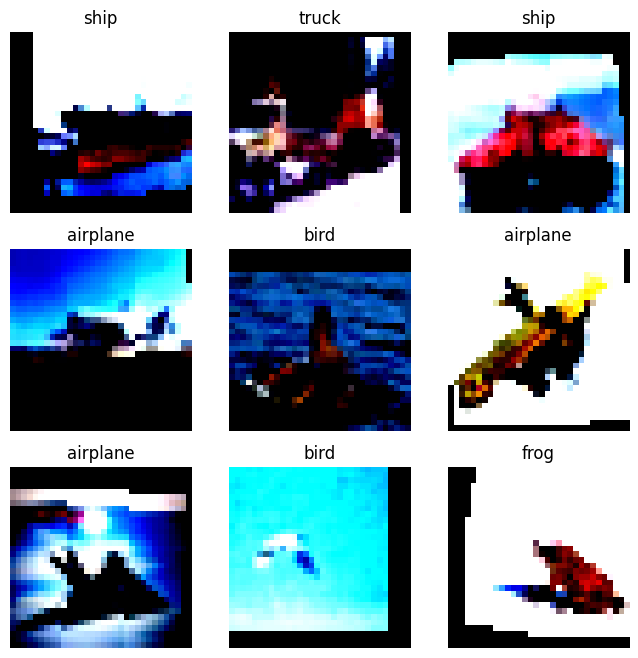

In [23]:
import torch
import matplotlib.pyplot as plt

labels_map = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), (1,)).item()
    img, label = training_data[sample_idx]

    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")

    # Convert from [C, H, W] → [H, W, C]
    plt.imshow(img.permute(1, 2, 0))

plt.show()

## Create model (Pytorch Implementation)

### Layer Creation

In [ ]:
# from model_pytorch import ReLU, SoftMax, Flatten, Conv2D, Linear
import torch.nn as nn
import math
# https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html#torch.nn.Sequential
# Use sequential to perform operations layer by layer

# Model Design:
# https://www.kaggle.com/code/ayushnitb/cifar10-custom-resnet-cnn-pytorch-97-acc

# Conv2D hyperparameters
in_channels = 3
conv1_out_channels = 32
conv2_out_channels = 64

kernel_size = 3
stride = 1
padding = 1

H_in = 32
W_in = 32

# Layer 1
layer1_conv = nn.Conv2d(
    in_channels=in_channels,
        out_channels=conv1_out_channels,
            kernel_size=kernel_size,
                stride=stride,
                    padding=padding
                    )
layer1_relu = nn.ReLU()

# Get max number from 2x2 grids across entire matrix -> New matrix
layer1_pool = nn.MaxPool2d(kernel_size=2)

# Layer 2
layer2_conv = nn.Conv2d(
in_channels=conv1_out_channels,
out_channels=conv2_out_channels,
kernel_size=kernel_size,
stride=stride,
padding=padding
)

layer2_relu = nn.ReLU()

layer2_pool = nn.MaxPool2d(kernel_size=2)

# Flatten
layer3_flatten = nn.Flatten()

# Fully Connected 
# Every pooling layer cuts dimensions in half (layer2: 64x16x16->64x8x8)
in_features = conv2_out_channels * 8 * 8
FC_output_features = 10

layer4_fc = nn.Linear(
in_features=in_features,
out_features=FC_output_features
)

# Softmax
layer5_softmax = nn.Softmax(dim=1)


"""
Runs the forward pass.

def forward(self, input):
for module in self:
input = module(input)
return input

"""

'\nRuns the forward pass.\n\ndef forward(self, input):\n    for module in self:\n        input = module(input)\n    return input\n\n'

In [25]:
import torch
# 1. Check for NVIDIA (CUDA)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print("TRUE")
    device = torch.device("cuda")
    print("NVIDIA CUDA detected")

# 2. Check for Intel (XPU)
# We use hasattr() because older versions of PyTorch might crash if you call torch.xpu directly
elif hasattr(torch, "xpu") and torch.xpu.is_available():
    device = torch.device("xpu")
    print("Intel XPU detected")

# 3. Check for Apple Silicon (MPS)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple Silicon MPS detected")

# 4. Fallback to CPU
else:
    device = torch.device("cpu")
    print("No hardware accelerator found. CPU")

print(f"Set to use device: {device}")

True
TRUE
NVIDIA CUDA detected
Set to use device: cuda


In [26]:
model = nn.Sequential(
    layer1_conv,
    nn.BatchNorm2d(32), 
    layer1_relu,
    layer1_pool,
    layer2_conv,
    nn.BatchNorm2d(64), 
    layer2_relu,
    layer2_pool,
    layer3_flatten,
    layer4_fc,
    # layer5_softmax - Calculated in CrossEntropyLoss
)
model = model.to(device)
cross_entropy_loss = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     lr=0.01,
#     momentum=0.9
# )
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
correct = 0
total = 0
epochs = 50

for epoch in range(epochs):

    correct = 0
    total = 0
    model.train()
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        # Clear old gradients
        optimizer.zero_grad()

        # Make predictions
        outputs = model(images)
        
        # Find difference between y & y_hat
        loss = cross_entropy_loss(outputs, labels)

        # Comput all gradients
        loss.backward()

        # Update model (w1,b1,...) using gradients 
        optimizer.step()

        _, predicted = torch.max(outputs, 1) # Uses the highest value as predicted class

        total += labels.size(0)
        # Count the number of predicted classes that are equal to the true label
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total



    print("Epoch:", epoch+1, "Accuracy:", accuracy)

Epoch: 1 Accuracy: 43.078
Epoch: 2 Accuracy: 53.332
Epoch: 3 Accuracy: 57.604
Epoch: 4 Accuracy: 60.294
Epoch: 5 Accuracy: 61.636
Epoch: 6 Accuracy: 62.818
Epoch: 7 Accuracy: 63.934
Epoch: 8 Accuracy: 64.884
Epoch: 9 Accuracy: 65.874
Epoch: 10 Accuracy: 66.354
Epoch: 11 Accuracy: 67.0
Epoch: 12 Accuracy: 67.654
Epoch: 13 Accuracy: 68.366
Epoch: 14 Accuracy: 68.256
Epoch: 15 Accuracy: 68.662
Epoch: 16 Accuracy: 69.49
Epoch: 17 Accuracy: 69.572
Epoch: 18 Accuracy: 69.896
Epoch: 19 Accuracy: 70.332
Epoch: 20 Accuracy: 70.814
Epoch: 21 Accuracy: 70.686
Epoch: 22 Accuracy: 71.096
Epoch: 23 Accuracy: 71.074
Epoch: 24 Accuracy: 71.398
Epoch: 25 Accuracy: 71.794
Epoch: 26 Accuracy: 72.1
Epoch: 27 Accuracy: 72.316
Epoch: 28 Accuracy: 72.584
Epoch: 29 Accuracy: 72.54
Epoch: 30 Accuracy: 72.83
Epoch: 31 Accuracy: 73.062
Epoch: 32 Accuracy: 73.302
Epoch: 33 Accuracy: 73.366
Epoch: 34 Accuracy: 73.176
Epoch: 35 Accuracy: 73.548
Epoch: 36 Accuracy: 73.786
Epoch: 37 Accuracy: 73.532
Epoch: 38 Accurac

In [27]:
torch.save(model.state_dict(), "cifar10_model_adam_normalize.pth")

In [28]:
def check_accuracy(loader, model, device):
    num_correct = 0
    num_samples = 0
    model.eval()
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            scores = model(x)
            _, predictions = scores.max(1)

            num_correct += (predictions == y).sum().item()
            num_samples += predictions.size(0)
        
    print(f'Got {num_correct} / {num_samples} with accuracy {num_correct/num_samples*100:.2f}')
    
    model.train()
check_accuracy(test_loader, model, device)

Got 7716 / 10000 with accuracy 77.16


Above code was overfit (90% training accuracy, 67% test accuracy) added Flipping roation cropping
